# 07 Tabular Model Tuning

Tune the primary tabular model families while preserving a fair comparison with the basic models.

- Recreate the same 500,000-row training sample and 300,000-row validation sample.
- Use smaller search subsets to compare candidate settings efficiently.
- Refit each winning configuration on all 500,000 training rows.
- Evaluate every final tuned model on the same 300,000 validation rows.
- Keep the chronological test dataset untouched.

The median baseline has no hyperparameters. Ordinary Linear Regression has very few useful settings, so Ridge candidates are included as regularized linear alternatives.

## Setup

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
TRAIN_SAMPLE_ROWS = 500_000
VALIDATION_SAMPLE_ROWS = 300_000
SEARCH_TRAIN_ROWS = 150_000
SEARCH_VALIDATION_ROWS = 100_000

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
modeling_dir = project_root / "data" / "processed" / "modeling"
reports_dir = project_root / "reports"
figures_dir = project_root / "figures"
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

## Recreate the Fixed Samples

In [2]:
def representative_sample(
    frame: pd.DataFrame,
    sample_rows: int,
    random_state: int,
) -> pd.DataFrame:
    if len(frame) <= sample_rows:
        return frame.copy()

    sample_fraction = sample_rows / len(frame)
    sampled = frame.groupby(
        ["site_id", "month", "primary_use"],
        observed=True,
        group_keys=False,
    ).sample(frac=sample_fraction, random_state=random_state)

    if len(sampled) > sample_rows:
        sampled = sampled.sample(n=sample_rows, random_state=random_state)
    elif len(sampled) < sample_rows:
        remaining = frame.loc[~frame.index.isin(sampled.index)]
        additional = remaining.sample(
            n=sample_rows - len(sampled),
            random_state=random_state,
        )
        sampled = pd.concat([sampled, additional], ignore_index=False)

    return sampled.sort_values("timestamp").reset_index(drop=True)


train_pool = pd.read_parquet(modeling_dir / "model_train.parquet")
validation_pool = pd.read_parquet(modeling_dir / "model_validation.parquet")

train_data = representative_sample(
    train_pool,
    TRAIN_SAMPLE_ROWS,
    RANDOM_STATE,
)
validation_data = representative_sample(
    validation_pool,
    VALIDATION_SAMPLE_ROWS,
    RANDOM_STATE,
)

del train_pool, validation_pool

pd.DataFrame(
    [
        {
            "dataset": "training",
            "rows": len(train_data),
            "start": train_data["timestamp"].min(),
            "end": train_data["timestamp"].max(),
        },
        {
            "dataset": "validation",
            "rows": len(validation_data),
            "start": validation_data["timestamp"].min(),
            "end": validation_data["timestamp"].max(),
        },
    ]
)

,dataset,rows,start,end
0,training,500000,2016-01-01,2016-09-12 23:00:00
1,validation,300000,2016-09-13,2016-11-06 23:00:00


## Use the Same Features and Preprocessing

In [3]:
def add_modeling_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["log_square_feet"] = np.log1p(result["square_feet"])
    result["building_age"] = (2016 - result["year_built"]).clip(lower=0)
    return result


train_data = add_modeling_features(train_data)
validation_data = add_modeling_features(validation_data)

numeric_features = [
    "log_square_feet",
    "building_age",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]
categorical_features = ["site_id", "primary_use"]
feature_columns = numeric_features + categorical_features
target_column = "meter_reading"

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                            dtype=np.float32,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

X_train = preprocessor.fit_transform(train_data[feature_columns]).astype(
    "float32"
)
X_validation = preprocessor.transform(
    validation_data[feature_columns]
).astype("float32")
y_train = train_data[target_column].to_numpy(dtype="float64")
y_validation = validation_data[target_column].to_numpy(dtype="float64")

random_generator = np.random.default_rng(RANDOM_STATE)
search_train_indices = np.sort(
    random_generator.choice(
        len(X_train),
        size=SEARCH_TRAIN_ROWS,
        replace=False,
    )
)
search_validation_indices = np.sort(
    random_generator.choice(
        len(X_validation),
        size=SEARCH_VALIDATION_ROWS,
        replace=False,
    )
)

X_search_train = X_train[search_train_indices]
y_search_train = y_train[search_train_indices]
X_search_validation = X_validation[search_validation_indices]
y_search_validation = y_validation[search_validation_indices]

X_train.shape, X_validation.shape, X_search_train.shape

((500000, 45), (300000, 45), (150000, 45))

## Tuning Helpers

In [4]:
def calculate_metrics(
    model_name: str,
    y_true: np.ndarray,
    predictions: np.ndarray,
    fit_seconds: float,
) -> dict:
    predictions = np.clip(predictions, a_min=0, a_max=None)
    return {
        "model": model_name,
        "rmse": np.sqrt(mean_squared_error(y_true, predictions)),
        "mae": mean_absolute_error(y_true, predictions),
        "r2": r2_score(y_true, predictions),
        "rmsle": np.sqrt(mean_squared_log_error(y_true, predictions)),
        "fit_seconds": fit_seconds,
    }


def tune_candidates(
    model_family: str,
    candidates: list,
) -> tuple[object, pd.DataFrame]:
    result_rows = []

    for candidate_number, model in enumerate(candidates, start=1):
        print(
            f"{model_family}: candidate {candidate_number}/{len(candidates)}"
        )
        start = perf_counter()
        model.fit(X_search_train, y_search_train)
        fit_seconds = perf_counter() - start
        predictions = np.clip(
            model.predict(X_search_validation),
            a_min=0,
            a_max=None,
        )
        metrics = calculate_metrics(
            model_family,
            y_search_validation,
            predictions,
            fit_seconds,
        )
        metrics.update(
            {
                "candidate": candidate_number,
                "parameters": model.get_params(),
            }
        )
        result_rows.append(metrics)

    results = pd.DataFrame(result_rows).sort_values("rmse").reset_index(
        drop=True
    )
    best_candidate = int(results.loc[0, "candidate"])
    return candidates[best_candidate - 1], results

## Candidate Configurations

In [5]:
linear_candidates = [
    LinearRegression(),
    Ridge(alpha=0.1),
    Ridge(alpha=1.0),
    Ridge(alpha=10.0),
    Ridge(alpha=100.0),
]

random_forest_candidates = [
    RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        max_features=1.0,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        max_features=0.7,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    RandomForestRegressor(
        n_estimators=200,
        max_depth=30,
        min_samples_leaf=2,
        max_features=0.5,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    RandomForestRegressor(
        n_estimators=250,
        max_depth=24,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    RandomForestRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=5,
        max_features=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
]

gradient_boosting_candidates = [
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=10,
        subsample=0.8,
        loss="squared_error",
        random_state=RANDOM_STATE,
    ),
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=10,
        subsample=0.8,
        loss="squared_error",
        random_state=RANDOM_STATE,
    ),
    GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=10,
        subsample=0.8,
        loss="squared_error",
        random_state=RANDOM_STATE,
    ),
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.08,
        max_depth=3,
        min_samples_leaf=20,
        subsample=0.9,
        loss="huber",
        random_state=RANDOM_STATE,
    ),
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        min_samples_leaf=20,
        subsample=0.8,
        loss="huber",
        random_state=RANDOM_STATE,
    ),
]

## Search for the Best Settings

In [6]:
best_linear_model, linear_tuning = tune_candidates(
    "Linear Model",
    linear_candidates,
)
best_random_forest, random_forest_tuning = tune_candidates(
    "Random Forest",
    random_forest_candidates,
)
best_gradient_boosting, gradient_boosting_tuning = tune_candidates(
    "Gradient Boosting",
    gradient_boosting_candidates,
)

tuning_results = pd.concat(
    [
        linear_tuning,
        random_forest_tuning,
        gradient_boosting_tuning,
    ],
    ignore_index=True,
).sort_values(["model", "rmse"])
tuning_results.to_csv(
    reports_dir / "tabular_tuning_search_results.csv",
    index=False,
)

display(
    tuning_results[
        ["model", "candidate", "rmse", "mae", "r2", "fit_seconds"]
    ]
)

best_parameters = pd.DataFrame(
    [
        {
            "model": "Linear Model",
            "parameters": best_linear_model.get_params(),
        },
        {
            "model": "Random Forest",
            "parameters": best_random_forest.get_params(),
        },
        {
            "model": "Gradient Boosting",
            "parameters": best_gradient_boosting.get_params(),
        },
    ]
)
best_parameters

Linear Model: candidate 1/5
Linear Model: candidate 2/5
Linear Model: candidate 3/5
Linear Model: candidate 4/5
Linear Model: candidate 5/5
Random Forest: candidate 1/5
Random Forest: candidate 2/5
Random Forest: candidate 3/5
Random Forest: candidate 4/5
Random Forest: candidate 5/5
Gradient Boosting: candidate 1/6
Gradient Boosting: candidate 2/6
Gradient Boosting: candidate 3/6
Gradient Boosting: candidate 4/6
Gradient Boosting: candidate 5/6
Gradient Boosting: candidate 6/6


,model,candidate,rmse,mae,r2,fit_seconds
10,Gradient Boosting,4,214.757366,82.729080,0.652044,53.589017
11,Gradient Boosting,1,223.364959,94.375387,0.623592,20.956751
12,Gradient Boosting,3,225.571509,95.797191,0.616119,49.788434
13,Gradient Boosting,2,225.606310,95.174693,0.616000,33.366409
14,Gradient Boosting,6,235.772616,88.854094,0.580613,65.482138
15,Gradient Boosting,5,243.379346,91.865354,0.553115,41.173260
0,Linear Model,1,282.881127,150.999087,0.396279,0.085955
1,Linear Model,2,282.881833,151.001337,0.396276,0.172017
2,Linear Model,3,282.883882,151.014875,0.396267,0.057317
3,Linear Model,4,282.906179,151.149735,0.396172,0.029234


,model,parameters
0,Linear Model,"{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}"
1,Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_lea..."
2,Gradient Boosting,"{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.05, 'loss': 'squared_..."


## Refit Winners on the Full Training Sample

In [7]:
final_models = {
    "Median Baseline": DummyRegressor(strategy="median"),
    "Tuned Linear Model": best_linear_model,
    "Tuned Random Forest": best_random_forest,
    "Tuned Gradient Boosting": best_gradient_boosting,
}

final_metric_rows = []

for model_name, model in final_models.items():
    print(f"Refitting {model_name}...")
    start = perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = perf_counter() - start
    predictions = np.clip(
        model.predict(X_validation),
        a_min=0,
        a_max=None,
    )
    final_metric_rows.append(
        calculate_metrics(
            model_name,
            y_validation,
            predictions,
            fit_seconds,
        )
    )

tuned_metrics = (
    pd.DataFrame(final_metric_rows)
    .sort_values("rmse")
    .reset_index(drop=True)
)
tuned_metrics.to_csv(
    reports_dir / "tuned_tabular_validation_metrics.csv",
    index=False,
)

tuned_metrics

Refitting Median Baseline...
Refitting Tuned Linear Model...
Refitting Tuned Random Forest...
Refitting Tuned Gradient Boosting...


,model,rmse,mae,r2,rmsle,fit_seconds
0,Tuned Random Forest,179.602784,33.302590,0.754937,0.701704,75.187594
1,Tuned Gradient Boosting,206.532112,81.131182,0.675939,1.155314,200.559945
2,Tuned Linear Model,320.293173,187.111380,0.220625,1.810480,0.343154
3,Median Baseline,382.036478,155.819121,-0.108819,1.630294,0.006701


## Compare Basic and Tuned Validation Results

In [8]:
basic_metrics = pd.read_csv(
    reports_dir / "basic_tabular_validation_metrics.csv"
)

basic_family_names = {
    "Median Baseline": "Median Baseline",
    "Linear Regression": "Linear Model",
    "Random Forest Regressor": "Random Forest",
    "Gradient Boosting Regressor": "Gradient Boosting",
}
tuned_family_names = {
    "Median Baseline": "Median Baseline",
    "Tuned Linear Model": "Linear Model",
    "Tuned Random Forest": "Random Forest",
    "Tuned Gradient Boosting": "Gradient Boosting",
}

basic_comparison = basic_metrics.copy()
basic_comparison["family"] = basic_comparison["model"].map(
    basic_family_names
)
tuned_comparison = tuned_metrics.copy()
tuned_comparison["family"] = tuned_comparison["model"].map(
    tuned_family_names
)

comparison = basic_comparison[
    ["family", "rmse", "mae", "r2", "rmsle"]
].merge(
    tuned_comparison[["family", "rmse", "mae", "r2", "rmsle"]],
    on="family",
    suffixes=("_basic", "_tuned"),
)
comparison["rmse_change"] = (
    comparison["rmse_tuned"] - comparison["rmse_basic"]
)
comparison["rmse_improvement_percent"] = (
    -comparison["rmse_change"] / comparison["rmse_basic"] * 100
)
comparison.sort_values("rmse_tuned")

,family,rmse_basic,mae_basic,r2_basic,rmsle_basic,rmse_tuned,mae_tuned,r2_tuned,rmsle_tuned,rmse_change,rmse_improvement_percent
0,Random Forest,179.602784,33.302590,0.754937,0.701704,179.602784,33.302590,0.754937,0.701704,0.000000e+00,-0.000000e+00
1,Gradient Boosting,224.760713,95.502974,0.616212,1.253040,206.532112,81.131182,0.675939,1.155314,-1.822860e+01,8.110226e+00
2,Linear Model,320.293173,187.111380,0.220625,1.810480,320.293173,187.111380,0.220625,1.810480,0.000000e+00,-0.000000e+00
3,Median Baseline,382.036478,155.819121,-0.108819,1.630294,382.036478,155.819121,-0.108819,1.630294,-5.684342e-14,1.487906e-14


## Tuning Comparison Visual

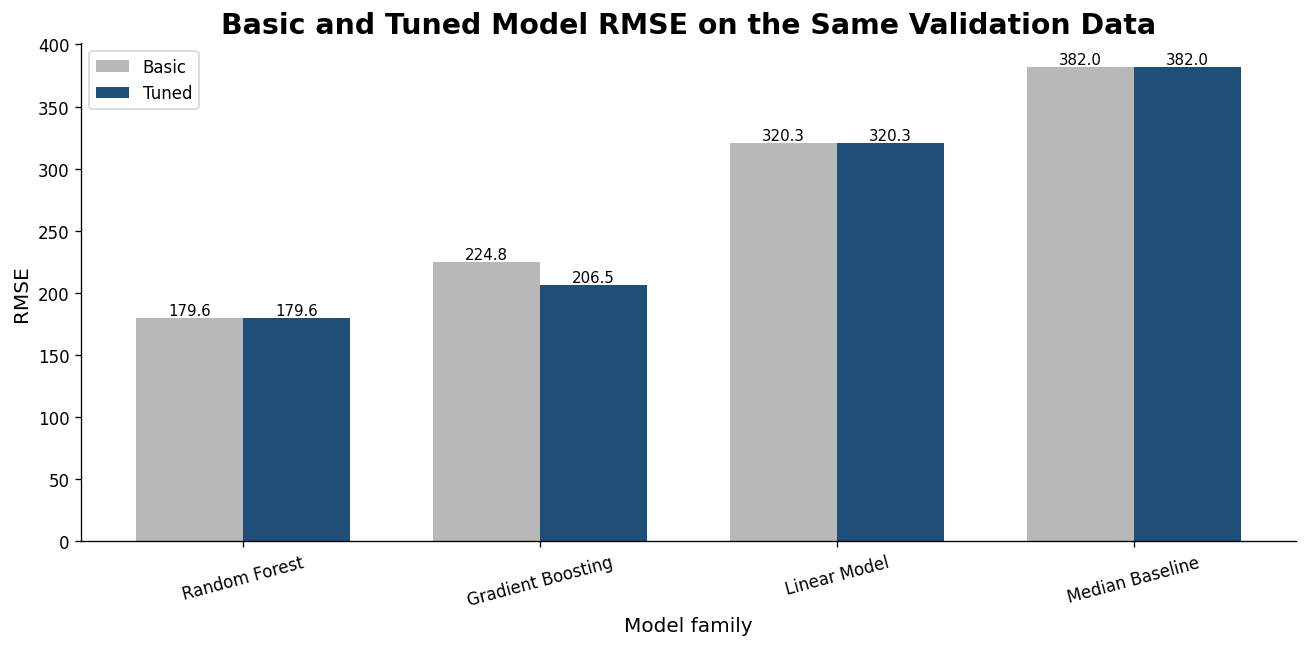

In [9]:
plot_data = comparison.sort_values("rmse_tuned").reset_index(drop=True)
x_positions = np.arange(len(plot_data))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

basic_bars = ax.bar(
    x_positions - bar_width / 2,
    plot_data["rmse_basic"],
    width=bar_width,
    color="#b8b8b8",
    label="Basic",
)
tuned_bars = ax.bar(
    x_positions + bar_width / 2,
    plot_data["rmse_tuned"],
    width=bar_width,
    color="#1f4e79",
    label="Tuned",
)

ax.set_title("Basic and Tuned Model RMSE on the Same Validation Data", fontsize=17, weight="bold")
ax.set_xlabel("Model family", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["family"], rotation=15)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

for bars in [basic_bars, tuned_bars]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:,.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
fig.savefig(
    figures_dir / "basic_vs_tuned_tabular_models.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Interpretation Rule

Select the strongest tuned tabular model using validation results. The test dataset remains untouched. In the next stage, refit the selected configuration and evaluate it once on the chronological test data. Keep the LSTM results separate because it uses historical meter-reading sequences and a different forecasting paradigm.